In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = r"c:\Users\santi\OneDrive\Desktop\9no Cuatri\Base de Datos\Conjunto de datos para 2a. evaluación-20260813"

# 1. Carga
ruta_comprar = os.path.join(BASE_PATH, 'comprar_alquilar.csv')
df_comprar = pd.read_csv(ruta_comprar)

# 2. Exploración
print("--- Información del Dataset ---")
df_comprar.info()

print("\n--- Estadísticas de las variables (Mucha atención a las escalas) ---")
display(df_comprar.describe().loc[['mean', 'min', 'max']])

# Separamos las variables (X) de la etiqueta de color (y)
X = df_comprar.drop('comprar', axis=1)
y_color = df_comprar['comprar'] # 0 = Alquilar, 1 = Comprar

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB

--- Estadísticas de las variables (Mucha atención a las escalas) ---


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
mean,4958.99505,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
min,2008.00000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
max,7984.00000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


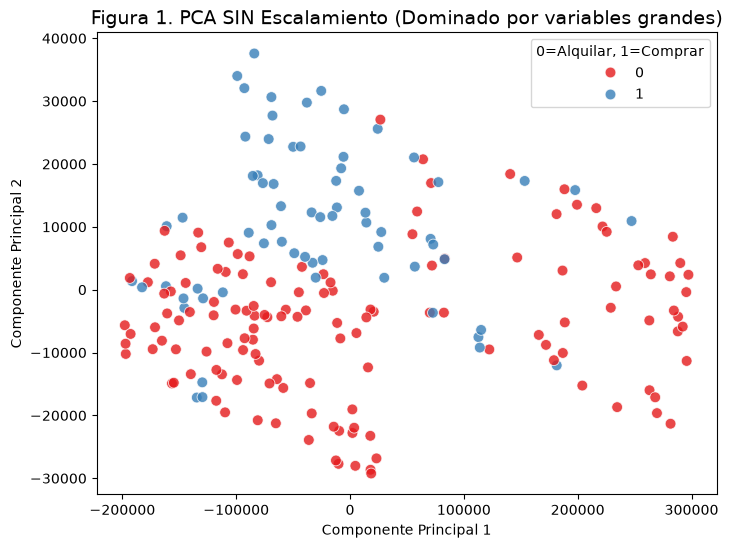

Varianza explicada sin escalar: [0.98986362 0.0100648 ]


In [2]:
# Aplicamos PCA directo a los datos crudos (Mala práctica)
pca_sin_escalar = PCA(n_components=2)
componentes_mal = pca_sin_escalar.fit_transform(X)

# Gráfica
plt.figure(figsize=(8, 6))
sns.scatterplot(x=componentes_mal[:, 0], y=componentes_mal[:, 1], 
                hue=y_color, palette='Set1', alpha=0.8, s=60)
plt.title('Figura 1. PCA SIN Escalamiento (Dominado por variables grandes)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='0=Alquilar, 1=Comprar')
plt.show()

print(f"Varianza explicada sin escalar: {pca_sin_escalar.explained_variance_ratio_}")

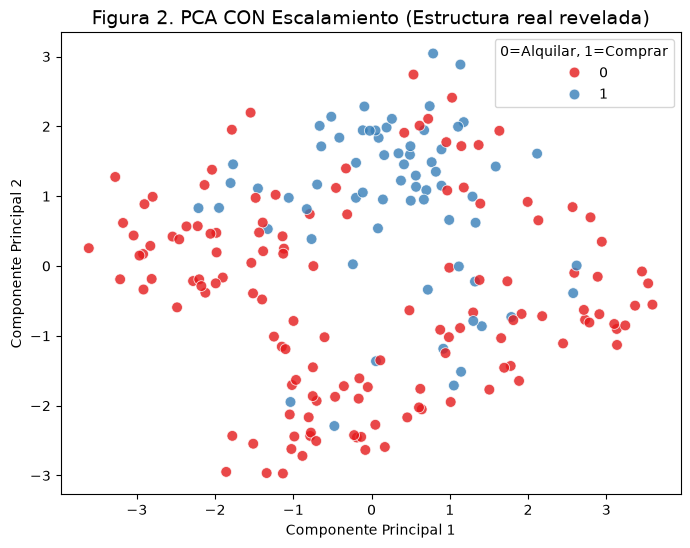

Varianza explicada con escalamiento: [0.29913557 0.23294923]


In [3]:
# 1. ESCALAMIENTO ESTÁNDAR
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# 2. Aplicamos PCA correcto
pca_escalado = PCA(n_components=2)
componentes_bien = pca_escalado.fit_transform(X_scaled)

# Gráfica
plt.figure(figsize=(8, 6))
sns.scatterplot(x=componentes_bien[:, 0], y=componentes_bien[:, 1], 
                hue=y_color, palette='Set1', alpha=0.8, s=60)
plt.title('Figura 2. PCA CON Escalamiento (Estructura real revelada)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='0=Alquilar, 1=Comprar')
plt.show()

print(f"Varianza explicada con escalamiento: {pca_escalado.explained_variance_ratio_}")

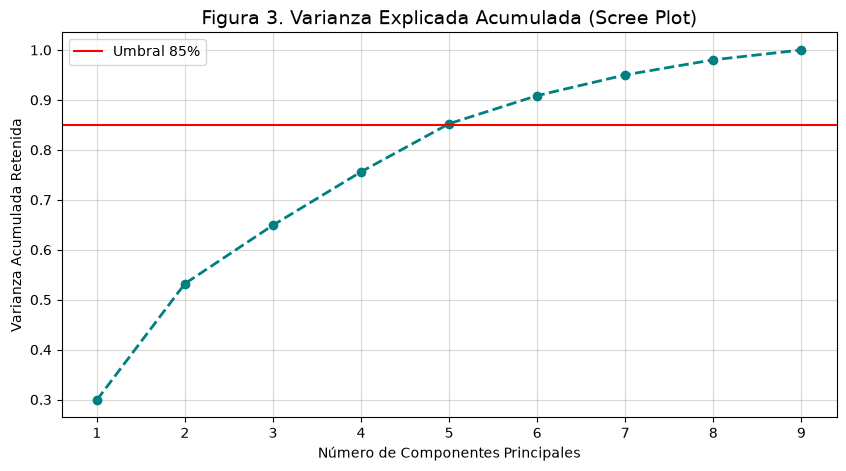

Con 1 componentes retienes el 29.91% de la información original.
Con 2 componentes retienes el 53.21% de la información original.
Con 3 componentes retienes el 64.92% de la información original.
Con 4 componentes retienes el 75.61% de la información original.
Con 5 componentes retienes el 85.24% de la información original.
Con 6 componentes retienes el 90.87% de la información original.
Con 7 componentes retienes el 95.02% de la información original.
Con 8 componentes retienes el 98.03% de la información original.
Con 9 componentes retienes el 100.00% de la información original.


In [4]:
# Aplicamos PCA con TODOS los componentes posibles (9 variables = 9 componentes) para ver el panorama completo
pca_total = PCA().fit(X_scaled)

# Calculamos la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_total.explained_variance_ratio_)

# Gráfica (Scree Plot)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), varianza_acumulada, marker='o', linestyle='--', color='teal', linewidth=2)
plt.axhline(y=0.85, color='r', linestyle='-', label='Umbral 85%') # Queremos retener ~85% de información

plt.title('Figura 3. Varianza Explicada Acumulada (Scree Plot)', fontsize=14)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Retenida')
plt.xticks(range(1, 10))
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

# Imprimimos los valores exactos
for i, var in enumerate(varianza_acumulada):
    print(f"Con {i+1} componentes retienes el {var*100:.2f}% de la información original.")

In [5]:
# Analizando la gráfica, con 5 componentes retenemos aprox el 85% de la información.
# Vamos a entrenar y guardar ese modelo definitivo.
n_optimo = 5 
pca_final = PCA(n_components=n_optimo)
pca_final.fit(X_scaled) # Lo entrenamos

joblib.dump(pca_final, 'modelo_comprar_pca.pkl')
joblib.dump(scaler_pca, 'scaler_comprar_pca.pkl')

var_final = sum(pca_final.explained_variance_ratio_) * 100
print(f"✅ Modelo guardado con {n_optimo} componentes (retiene el {var_final:.2f}% de la información).")

✅ Modelo guardado con 5 componentes (retiene el 85.24% de la información).
